# ML Project: Bankruptcy Risk Prediction

The objective is to develop a machine learning model that predicts the bankruptcy risk of a company based on financial and temporal variables. The document's structure spans from the presentation of the use case and motivation to the final interpretation of the models, offering a comprehensive overview of the analytical and decision-making process.

**Environment** · Python 3.10

_Last edited: Apr 25, 2025_

## Table of Contents

- [Dependency Installation](#dependency-installation)
- [Imports and Environment Setup](#imports-and-environment-setup)
- [1. Use Case Presentation and Motivation](#1-use-case-presentation-and-motivation)
- [2. Dataset Analysis](#2-dataset-analysis)
- [3. Preprocessing and Feature Extraction](#3-preprocessing-and-feature-extraction)
- [4. Validation Strategy and Model Evaluation](#4-validation-strategy-and-model-evaluation)
- [5. Modeling and Evaluation](#5-modeling-and-evaluation)
  - [Logistic Regression Model Evaluation](#logistic-regression-model-evaluation)
  - [K‑Nearest Neighbors Model Evaluation](#k-nearest-neighbors-model-evaluation)
  - [SVM Model Evaluation](#svm-model-evaluation)
  - [Random Forest Model Evaluation](#random-forest-model-evaluation)
  - [XGBoost Model Evaluation](#xgboost-model-evaluation)
- [6. Model Interpretability with SHAP](#6-model-interpretability-with-shap)
- [7. Conclusions and Next Steps](#7-conclusions-and-next-steps)
- [Optional Cell – Saving the Final Model](#optional-cell--saving-the-final-model)


## Dependency Installation

To run this project, you need to use Python 3.10 or later and install a set of dependencies that facilitate data analysis and machine learning model implementation. You can install all required libraries and packages by uncommenting and running the following line of code:

> **Hardware specifications**
> - **CPU:** 12 vCPUs
> - **RAM:** 16 GB
> - **GPU:** *Not used* (100% CPU training)
> - **Maximum training time per evaluation cell:** 20 seconds

In [1]:
# !pip -q install \
#     joblib==1.4.2 \
#     matplotlib==3.7.5 \
#     numpy==1.26.4 \
#     pandas==2.2.3 \
#     scikit-learn==1.2.2 \
#     scipy==1.15.2 \
#     seaborn==0.12.2 \
#     shap==0.44.1 \
#     tsfresh==0.21.0 \
#     xgboost==2.0.3

## Imports and Environment Setup

This section imports the necessary libraries and configures the environment to ensure project reproducibility. To dive deeper into each tool, you can consult the [official scikit-learn documentation](https://scikit-learn.org), [tsfresh documentation](https://tsfresh.readthedocs.io), and [SHAP documentation](https://shap.readthedocs.io).

In [2]:
import multiprocessing
import time
from collections.abc import Iterable
from typing import Any, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, 
    RocCurveDisplay, roc_auc_score
)
from sklearn.model_selection import BaseCrossValidator, StratifiedGroupKFold, StratifiedKFold, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import SVC

from xgboost import XGBClassifier

from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters
from tsfresh.transformers import FeatureSelector

import shap

SEED = 42

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


## 1. Use Case Presentation and Motivation

Early detection of financial *distress* is vital for both companies and financial institutions.

- **Use case:** predict a company's bankruptcy risk based on its financial indicators and the temporal dimension `Time`.
- **Motivation:** early identification of warning signs enables corrective actions and minimizes losses. Leveraging machine learning techniques and automatic temporal feature extraction with [tsfresh](https://tsfresh.readthedocs.io) adds precision and robustness.
- **Inspiration:** the idea to apply `tsfresh` came after reviewing the [Kaggle notebook on multivariate time series feature extraction](https://www.kaggle.com/code/aledelunap/multivariate-time-series-feature-extraction). It helped accelerate the temporal feature extraction I was manually implementing and avoid re-creating existing tools.

In summary, the project has evolved from original ideas, adopting established tools to keep the code clean, organized, and free of unnecessary complexity.

## 2. Dataset Analysis

This section loads and performs an initial exploration of the **Financial Distress** dataset.

- **Source:** [Financial Distress Prediction on Kaggle](https://www.kaggle.com/datasets/shebrahimi/financial-distress) (`Financial Distress.csv`).
- **Initial dimensions:** 3,672 rows × 86 columns.

Key aspects covered include:

- Creating the target variable `DistressFlag` from the original `Financial Distress` variable (threshold -0.5 according to the dataset description).
- Handling categorical variables (`x80`).
- Reviewing initial records and descriptive statistics with `head()`, `info()`, and `describe()`.
- Identifying missing and duplicate values, along with visualizations to understand class distribution and balance.

This initial exploration allows assessing data quality and structure, facilitating decision-making for subsequent preprocessing and modeling stages.

In [3]:
# data_path = '/kaggle/input/financial-distress/Financial Distress.csv'
data_path = 'Financial Distress.csv'
df = pd.read_csv(data_path)

distress_threshold = -0.5
df['DistressFlag'] = np.where(df['Financial Distress'] > distress_threshold, 0, 1)
df = df.drop('Financial Distress', axis=1)

cat_features = [
    'x80'
]
df[cat_features] = df[cat_features].astype('category')

print("Dataset dimensions:", df.shape)
df.head()

Dataset dimensions: (3672, 86)


,Company,Time,x1,x2,x3,x4,x5,x6,x7,x8,...,x75,x76,x77,x78,x79,x80,x81,x82,x83,DistressFlag
0,1,1,1.2810,0.022934,0.87454,1.21640,0.060940,0.188270,0.52510,0.018854,...,27.07,26.102,16.000,16.0,0.2,22,0.060390,30,49,0
1,1,2,1.2700,0.006454,0.82067,1.00490,-0.014080,0.181040,0.62288,0.006423,...,31.31,30.194,17.000,16.0,0.4,22,0.010636,31,50,0
2,1,3,1.0529,-0.059379,0.92242,0.72926,0.020476,0.044865,0.43292,-0.081423,...,36.07,35.273,17.000,15.0,-0.2,22,-0.455970,32,51,0
3,1,4,1.1131,-0.015229,0.85888,0.80974,0.076037,0.091033,0.67546,-0.018807,...,39.80,38.377,17.167,16.0,5.6,22,-0.325390,33,52,1
4,2,1,1.0623,0.107020,0.81460,0.83593,0.199960,0.047800,0.74200,0.128030,...,27.07,26.102,16.000,16.0,0.2,29,1.251000,7,27,0


In [4]:
df.info()
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3672 entries, 0 to 3671
Data columns (total 86 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Company       3672 non-null   int64   
 1   Time          3672 non-null   int64   
 2   x1            3672 non-null   float64 
 3   x2            3672 non-null   float64 
 4   x3            3672 non-null   float64 
 5   x4            3672 non-null   float64 
 6   x5            3672 non-null   float64 
 7   x6            3672 non-null   float64 
 8   x7            3672 non-null   float64 
 9   x8            3672 non-null   float64 
 10  x9            3672 non-null   float64 
 11  x10           3672 non-null   float64 
 12  x11           3672 non-null   float64 
 13  x12           3672 non-null   float64 
 14  x13           3672 non-null   float64 
 15  x14           3672 non-null   float64 
 16  x15           3672 non-null   float64 
 17  x16           3672 non-null   float64 
 18  x17     

,count,mean,std,min,25%,50%,75%,max
Company,3672.0,182.084423,117.024636,1.000000,80.000000,168.000000,264.250000,422.00000
Time,3672.0,7.528322,4.064016,1.000000,4.000000,7.000000,11.000000,14.00000
x1,3672.0,1.387820,1.452926,0.075170,0.952145,1.183600,1.506475,51.95400
x2,3672.0,0.129706,0.120013,-0.258080,0.048701,0.107530,0.188685,0.74941
x3,3672.0,0.615769,0.177904,0.016135,0.501888,0.638690,0.749425,0.96790
...,...,...,...,...,...,...,...,...
x79,3672.0,-2.664305,8.192663,-20.200000,-7.000000,0.200000,2.100000,8.60000
x81,3672.0,1.100488,2.666733,-0.499220,0.189912,0.594765,1.355050,128.40000
x82,3672.0,13.122277,9.465907,1.000000,6.000000,11.000000,17.000000,49.00000
x83,3672.0,33.044935,13.714563,2.000000,21.000000,34.000000,44.000000,74.00000


In [5]:
print("Missing values in the dataset:", df.isnull().sum().sum())
print("Duplicate rows in the dataset:", df.duplicated().sum(), "\n")

Missing values in the dataset: 0
Duplicate rows in the dataset: 0 



In [6]:
print("Total number of companies:", df['Company'].nunique())
print("Total number of time periods:", df['Time'].nunique())

Total number of companies: 422
Total number of time periods: 14


DistressFlag
0    3536
1     136
Name: count, dtype: int64

Target variable proportion:
DistressFlag
0    0.962963
1    0.037037
Name: count, dtype: float64


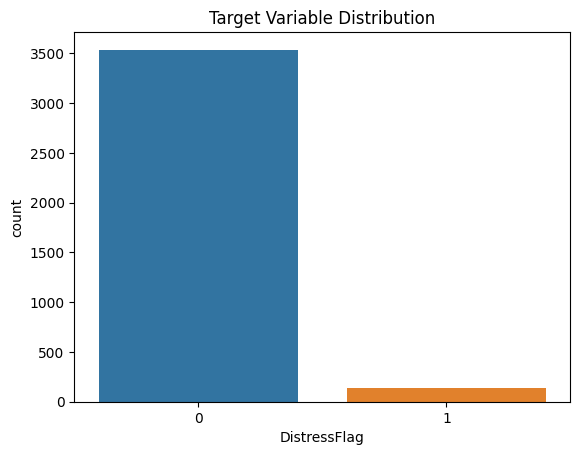

In [7]:
target_counts = df['DistressFlag'].value_counts()
print(target_counts)
print("\nTarget variable proportion:")
print(target_counts / df.shape[0])

sns.countplot(x='DistressFlag', data=df)
plt.title("Target Variable Distribution")
plt.show()

DistressFlag
0    286
1    136
Name: count, dtype: int64

Target proportion (by company):
DistressFlag
0    0.677725
1    0.322275
Name: count, dtype: float64


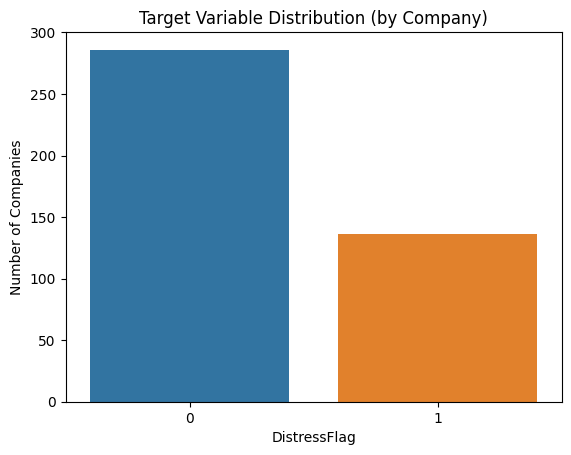

In [8]:
distress_per_company = df.groupby('Company')['DistressFlag'].last()

target_counts = distress_per_company.value_counts()
print(target_counts)
print("\nTarget proportion (by company):")
print(target_counts / distress_per_company.shape[0])

sns.countplot(x=distress_per_company)
plt.title("Target Variable Distribution (by Company)")
plt.xlabel("DistressFlag")
plt.ylabel("Number of Companies")
plt.show()

In [9]:
total_distress_records = df['DistressFlag'].value_counts()[1]

distress_flag_last_period = df.groupby('Company')['DistressFlag'].last()
companies_distress_last_period = distress_flag_last_period.value_counts()[1]

print("Total distress records in the dataset:", total_distress_records)
print("Companies in distress in their last period:", companies_distress_last_period)

Total distress records in the dataset: 136
Companies in distress in their last period: 136


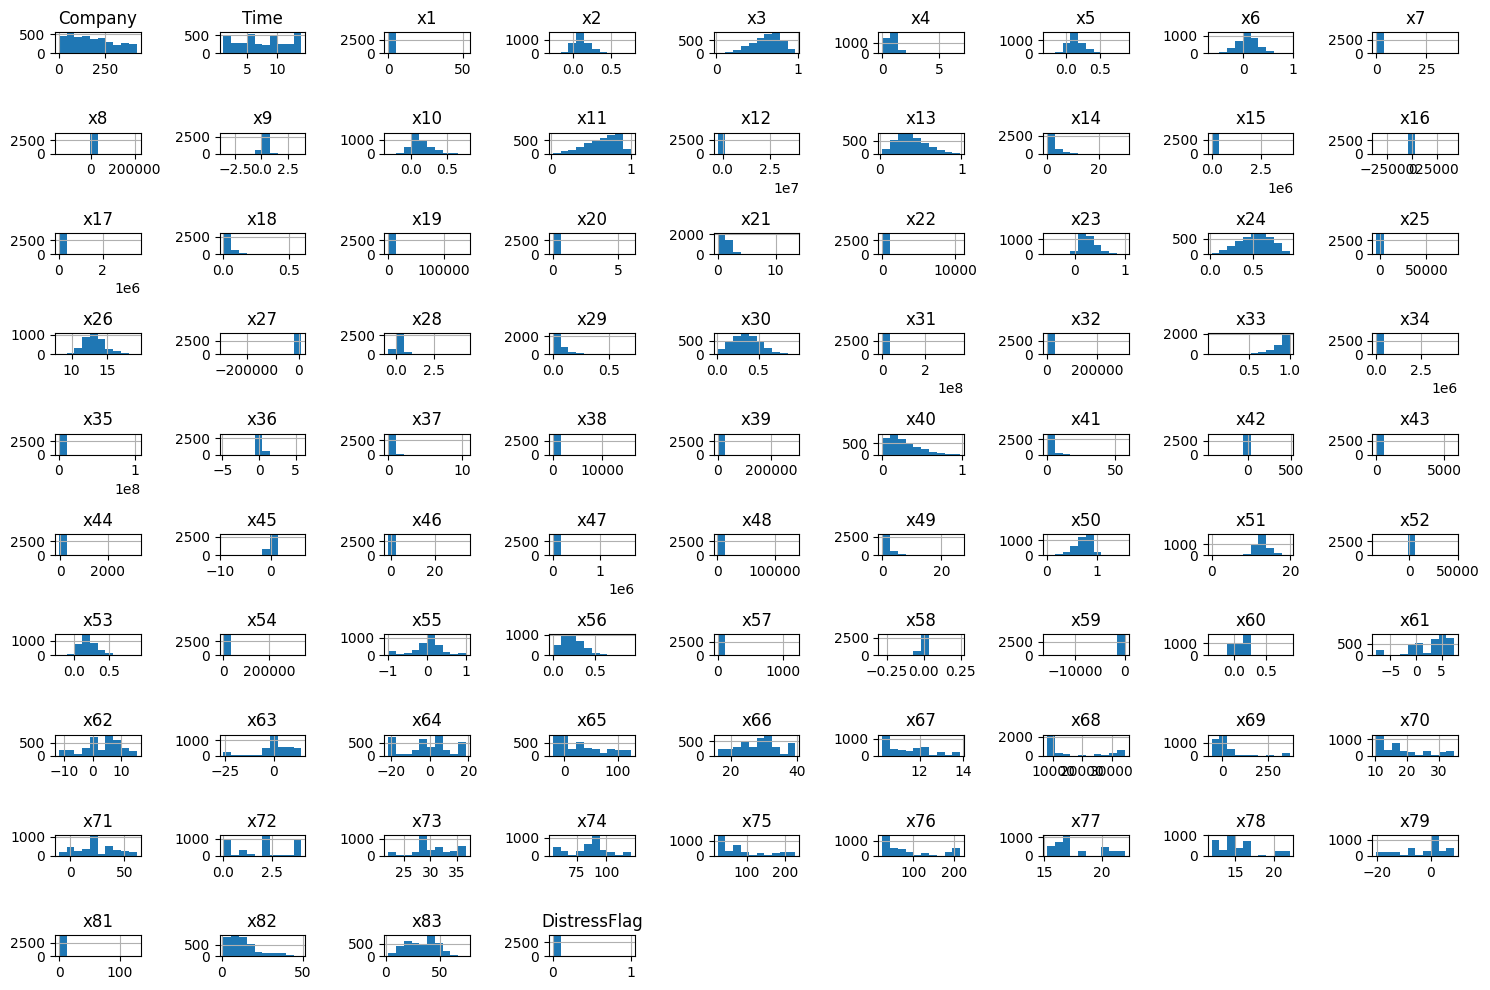

In [10]:
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

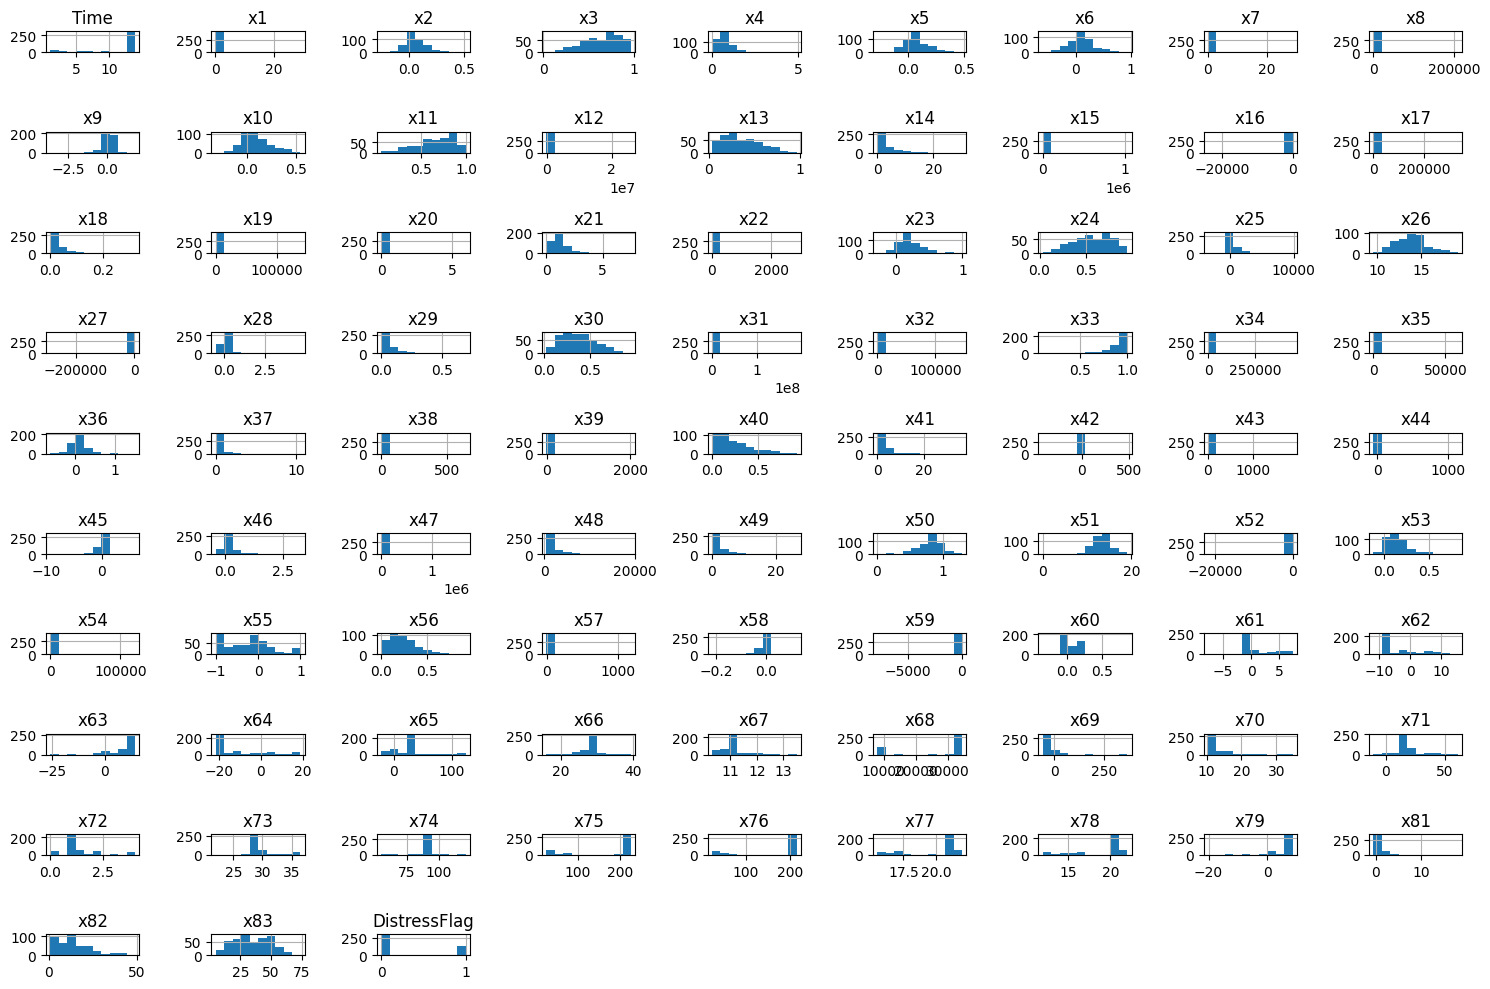

In [11]:
df_last_time_company = df.sort_values('Time')
df_last_time_company = df_last_time_company.groupby('Company').last()
df_last_time_company.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

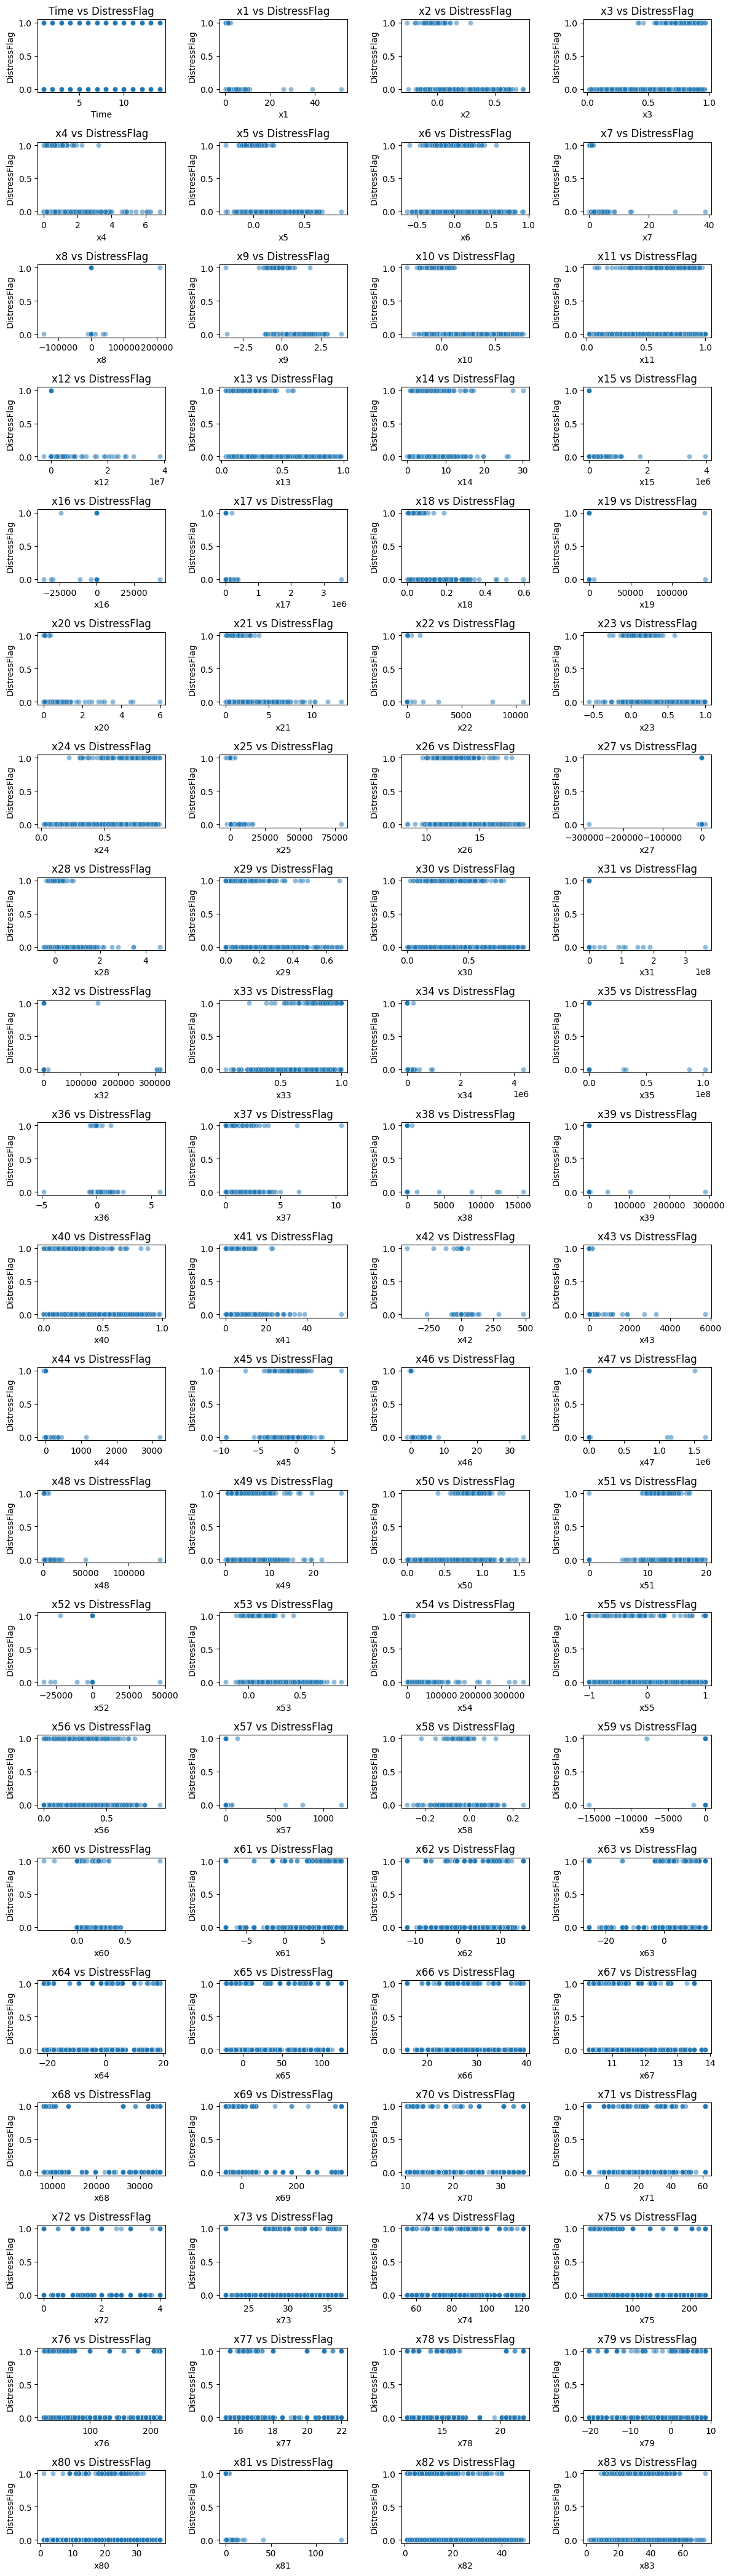

In [12]:
features = [col for col in df.columns if col not in ['Company', 'DistressFlag']]
n_features = len(features)

cols = 4
rows = n_features // cols + (n_features % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2 * rows))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.scatterplot(x=feature, y='DistressFlag', data=df, alpha=0.5, ax=ax)
    ax.set_title(f'{feature} vs DistressFlag')
    ax.set_xlabel(feature)
    ax.set_ylabel('DistressFlag')

for ax in axes[len(features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

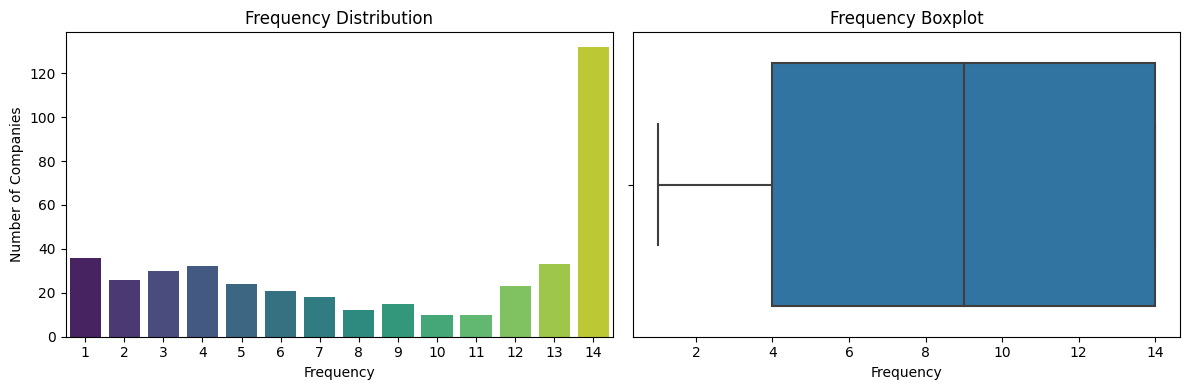

In [ ]:
freq = df['Company'].value_counts()

freq_dist = freq.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(x=freq_dist.index, y=freq_dist.values, ax=axes[0])
axes[0].set_title("Frequency Distribution")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Number of Companies")

sns.boxplot(x=freq.values, ax=axes[1])
axes[1].set_title("Frequency Boxplot")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


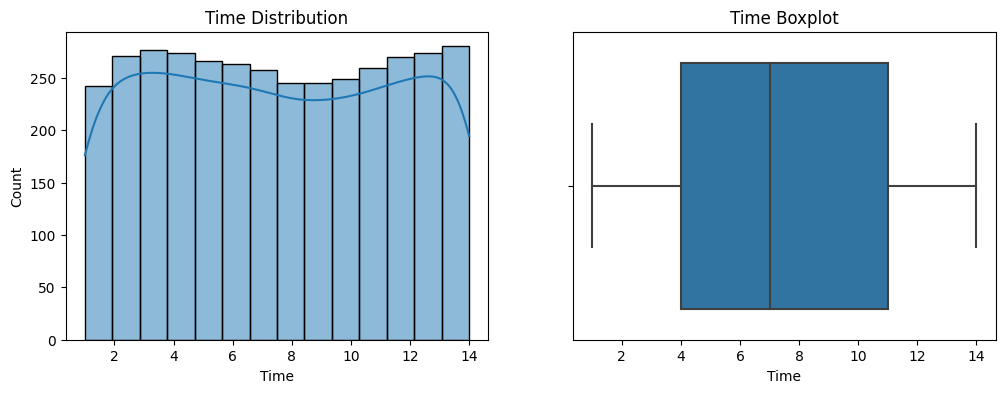

In [14]:
time_max = df['Time'].max()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Time'], ax=axes[0], bins=time_max, kde=True)
axes[0].set_title("Time Distribution")
sns.boxplot(x=df['Time'], ax=axes[1])
axes[1].set_title("Time Boxplot")
plt.show()

## 3. Preprocessing and Feature Extraction

This stage focuses on preparing the dataset for modeling by generating different data subsets:

1. **Full dataset** — exhibits significant class imbalance.
2. **Last year per company** (`X_last_time`) — uses the most recent snapshot for each company.
3. **Features extracted with tsfresh** (`X_extracted`) — captures each company's temporal dynamics.

> **Note:** Reindex `Company` so its values range from `0` to `n-1` to avoid index misalignment during cross-validation.

Integrating these variants facilitates evaluating the impact of each preprocessing approach on the model's predictive performance.

In [15]:
df['Company'] = df['Company'].apply(lambda x: x - 1)

In [16]:
n_jobs = max(1, multiprocessing.cpu_count() - 1)

df = df.sort_values('Time')

X = df.drop(columns=['DistressFlag', 'Company', 'Time'])
y = df['DistressFlag']

X_last_time = df.groupby('Company').last().drop(columns=['DistressFlag', 'Time'])
y_last_time = df.groupby('Company')['DistressFlag'].last()

fc_params = MinimalFCParameters()

X_extracted = extract_features(df.drop(columns=['DistressFlag'] + cat_features), column_id='Company', column_sort='Time', default_fc_parameters=fc_params, n_jobs=n_jobs)
X_extracted = pd.concat([X_extracted, X_last_time.copy()], axis=1)
y_extracted = df.groupby('Company')['DistressFlag'].last()

print("Original dataset dimensions:\n", X.shape)
print("Last-year dataset dimensions:\n", X_last_time.shape)
print("Extracted dataset dimensions:\n", X_extracted.shape)

Feature Extraction: 100%|██████████| 55/55 [00:03<00:00, 16.33it/s]


Original dataset dimensions:
 (3672, 83)
Last-year dataset dimensions:
 (422, 83)
Extracted dataset dimensions:
 (422, 903)


## 4. Validation Strategy and Model Evaluation

Two main strategies are used to evaluate model performance in an imbalanced problem:

- **Stratified Cross-Validation (`StratifiedKFold`)** – maintains class proportion in each fold.
- **Stratified Group Cross-Validation (`StratifiedGroupKFold`)** – ensures that a company's instances do not appear in both training and testing.

The following models will be evaluated, applying scaling when necessary:

- **Logistic Regression**
- **K-Nearest Neighbors (KNN)**
- **SVM**
- **Random Forest**
- **XGBoost**

The `evaluate_model` function calculates metrics (confusion matrix, classification report, AUC, F1, execution time) and generates the ROC curve to facilitate model comparison.

In [17]:
def calculate_metrics(
        y_true: np.ndarray,
        y_pred: np.ndarray,
        y_probs: np.ndarray
    ) -> Dict[str, Any]:
    """
    Calculates basic model metrics.

    Parameters:
    - y_true: Array of true labels.
    - y_pred: Array of predicted labels.
    - y_probs: Array of predicted probabilities for the positive class.
    
    Returns:
    - Dictionary with confusion matrix, classification report, AUC, and F1 Score.
    """
    return {
        'confusion_matrix': confusion_matrix(y_true, y_pred),
        'classification_report': classification_report(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_probs),
        'f1_score': f1_score(y_true, y_pred)
    }

def evaluate_model(
        estimator: BaseEstimator,
        X: pd.DataFrame,
        y: np.ndarray,
        cv: int | BaseCrossValidator | Iterable | None = None,
        groups: np.ndarray | None = None,
        threshold: float = 0.5
    ) -> Dict[str, Any]:
    """
    Evaluates an ML model using cross-validation, computing metrics and plotting the ROC curve.
    
    Parameters:
    - estimator: ML model or Pipeline to evaluate (e.g., SVC, KNeighborsClassifier).
    - X: Feature DataFrame or array.
    - y: True label array.
    - cv: Cross-validation strategy (e.g., StratifiedKFold).
    - groups: Groups for cross-validation (optional).
    - threshold: Threshold to convert probabilities into binary predictions.
    
    Returns:
    - Dictionary with calculated metrics and execution time.
    """
    start_time = time.time()
    
    y_probs: np.ndarray = cross_val_predict(
        estimator,
        X,
        y,
        cv=cv,
        groups=groups,
        n_jobs=-1,
        method='predict_proba'
    )[:, 1]

    y_pred: np.ndarray = (y_probs >= threshold).astype(int)
    
    metrics: Dict[str, Any] = calculate_metrics(y, y_pred, y_probs)
    
    execution_time: float = time.time() - start_time
    metrics['execution_time'] = execution_time

    print("Model metrics:")
    print(metrics['confusion_matrix'])
    print(metrics['classification_report'])
    print(f"ROC AUC: {metrics['roc_auc']:.4f}")
    print(f"F1 Score: {metrics['f1_score']:.4f}")
    print(f"Execution time: {execution_time:.2f} seconds")

    RocCurveDisplay.from_predictions(y, y_probs)
    plt.show()

    return metrics

In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

groups = df['Company'].values

## 5. Modeling and Evaluation

To facilitate comparison, all evaluations use **three data subsets**:

1. **Full dataset** – all available observations.
2. **Last year per company** (`X_last_time`) – most recent snapshot for each company.
3. **Features extracted with tsfresh** (`X_extracted`) – statistics generated from the time series.

### Preprocessing Pipeline (`make_preprocessor`)

The same pipeline is reused for all five classifiers:

1. **`reset_index`**  
   Resets the DataFrame index so stratified group validation does not encounter duplicate indices.
2. **`ColumnTransformer`**  
   - **Numerical variables**  
     - `SimpleImputer(strategy="median")`  
     - Optional scaling (`StandardScaler`) when the model requires it.  
   - **Categorical variables**  
     - `SimpleImputer(strategy="most_frequent")`  
     - `OneHotEncoder(handle_unknown="ignore", sparse_output=False)`  
   The transformer returns a `DataFrame` (`set_output(transform="pandas")`) preserving column names for better visualization during model interpretation.
3. **`FeatureSelector`** (tsfresh)  
   Automatically filters the most relevant features, reducing dimensionality before the classifier.

Each model (Logistic Regression, KNN, SVM, Random Forest, XGBoost) is wrapped in a `Pipeline` with this preprocessing, ensuring that imputation, scaling, and selection steps occur **inside** cross-validation, thus preventing data leakage.

In [19]:
def make_preprocessor(scaler: Optional[TransformerMixin] = None) -> Pipeline:
    """
    Creates a complete preprocessing Pipeline.

    Parameters:
    - scaler: Optional transformer for scaling numerical variables (e.g., StandardScaler). If None, no scaling is applied.

    Returns:
    - sklearn Pipeline including:
      * reset_index,
      * ColumnTransformer for imputation, scaling, and one-hot encoding,
      * tsfresh FeatureSelector.
    """
    reset = ('reset_index', FunctionTransformer(lambda X: X.reset_index(drop=True)))

    numeric_steps = [
        ('imputer', SimpleImputer(strategy='median'))
    ]
    if scaler is not None:
        numeric_steps.append(('scaler', scaler))
    numeric_transformer = Pipeline(steps=numeric_steps)

    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ))
    ])

    column_transform = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, make_column_selector(dtype_exclude='category')),
            ('cat', categorical_transformer, make_column_selector(dtype_include='category'))
        ],
        remainder='drop',
        verbose_feature_names_out=False
    ).set_output(transform='pandas')

    feature_selection = ('feature_selector', FeatureSelector())

    return Pipeline(steps=[
        reset,
        ('column_transform', column_transform),
        feature_selection
    ])

### Logistic Regression Model Evaluation

Model on original data:
Model metrics:
[[3502   34]
 [ 111   25]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3536
           1       0.42      0.18      0.26       136

    accuracy                           0.96      3672
   macro avg       0.70      0.59      0.62      3672
weighted avg       0.95      0.96      0.95      3672

ROC AUC: 0.9232
F1 Score: 0.2564
Execution time: 6.57 seconds


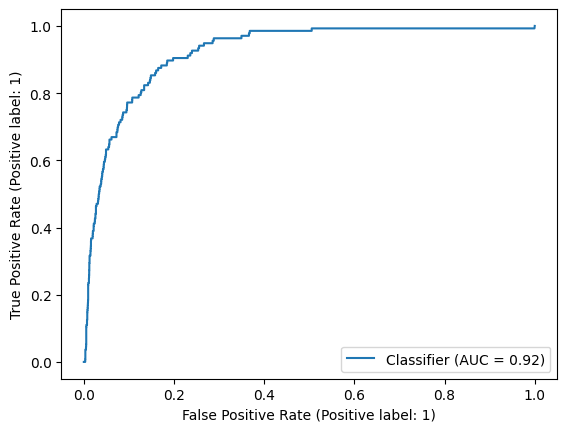

Model on last-year data:
Model metrics:
[[273  13]
 [ 15 121]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       286
           1       0.90      0.89      0.90       136

    accuracy                           0.93       422
   macro avg       0.93      0.92      0.92       422
weighted avg       0.93      0.93      0.93       422

ROC AUC: 0.9741
F1 Score: 0.8963
Execution time: 5.56 seconds


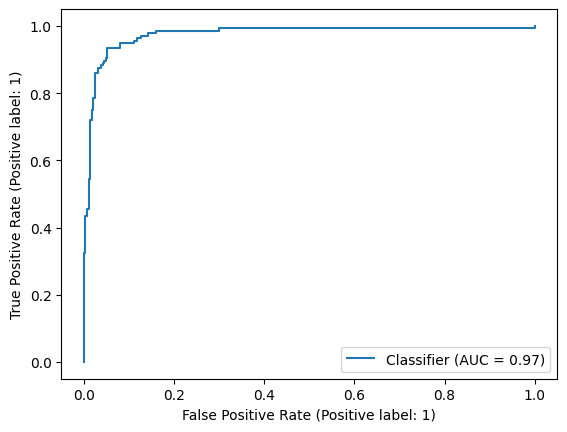

Model on extracted features:
Model metrics:
[[269  17]
 [ 15 121]]
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       286
           1       0.88      0.89      0.88       136

    accuracy                           0.92       422
   macro avg       0.91      0.92      0.91       422
weighted avg       0.92      0.92      0.92       422

ROC AUC: 0.9653
F1 Score: 0.8832
Execution time: 6.27 seconds


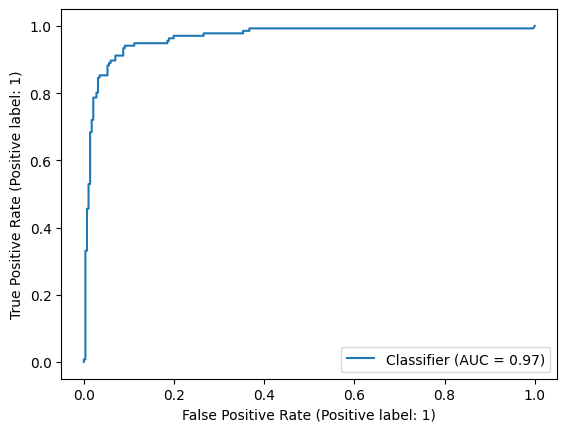

In [20]:
lr_params = {
    'random_state': SEED,
    'max_iter': 1000,
    'solver': 'lbfgs',
    'n_jobs': -1
}

lr_pipeline = Pipeline([
    ('preprocessor', make_preprocessor(scaler=StandardScaler())),
    ('model', LogisticRegression(**lr_params))
])

print("Model on original data:")
lr_base_eval = evaluate_model(
    lr_pipeline,
    X,
    y,
    cv=sgkf,
    groups=groups
)
print("Model on last-year data:")
lr_last_time_eval = evaluate_model(
    lr_pipeline,
    X_last_time,
    y_last_time,
    cv=skf
)
print("Model on extracted features:")
lr_extracted_eval = evaluate_model(
    lr_pipeline,
    X_extracted,
    y_extracted,
    cv=skf
)

### K-Nearest Neighbors Model Evaluation

Model on original data:
Model metrics:
[[3512   24]
 [ 119   17]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3536
           1       0.41      0.12      0.19       136

    accuracy                           0.96      3672
   macro avg       0.69      0.56      0.59      3672
weighted avg       0.95      0.96      0.95      3672

ROC AUC: 0.7811
F1 Score: 0.1921
Execution time: 4.84 seconds


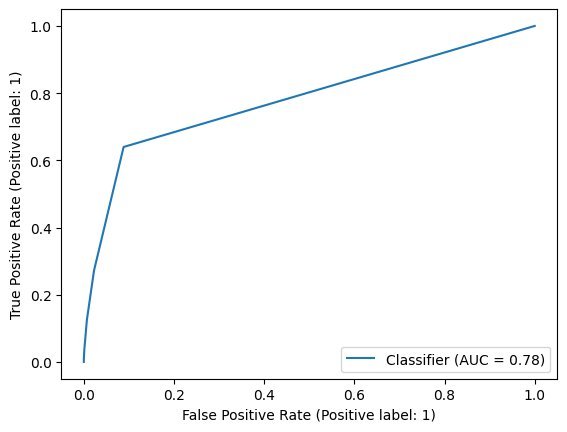

Model on last-year data:
Model metrics:
[[273  13]
 [ 18 118]]
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       286
           1       0.90      0.87      0.88       136

    accuracy                           0.93       422
   macro avg       0.92      0.91      0.92       422
weighted avg       0.93      0.93      0.93       422

ROC AUC: 0.9601
F1 Score: 0.8839
Execution time: 4.66 seconds


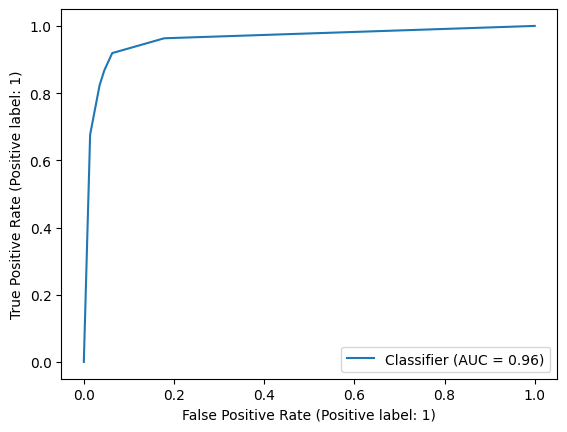

Model on extracted features:
Model metrics:
[[272  14]
 [ 21 115]]
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       286
           1       0.89      0.85      0.87       136

    accuracy                           0.92       422
   macro avg       0.91      0.90      0.90       422
weighted avg       0.92      0.92      0.92       422

ROC AUC: 0.9537
F1 Score: 0.8679
Execution time: 6.85 seconds


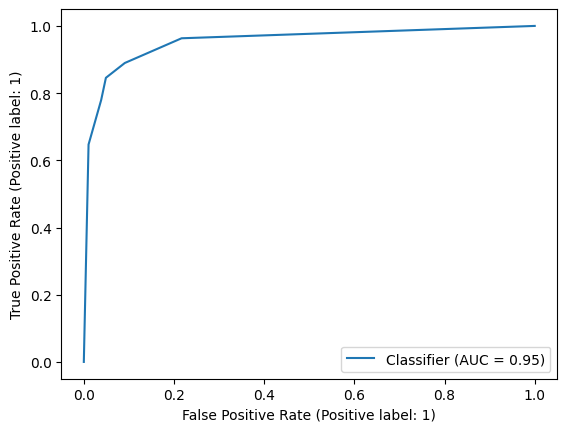

In [21]:
knn_params = {
    'n_neighbors': 5,
    'n_jobs': -1
}

knn_pipeline = Pipeline([
    ('preprocessor', make_preprocessor(scaler=StandardScaler())),
    ('model', KNeighborsClassifier(**knn_params))
])

print("Model on original data:")
knn_base_eval = evaluate_model(
    knn_pipeline,
    X,
    y,
    cv=sgkf,
    groups=groups
)
print("Model on last-year data:")
knn_last_time_eval = evaluate_model(
    knn_pipeline,
    X_last_time,
    y_last_time,
    cv=skf
)
print("Model on extracted features:")
knn_extracted_eval = evaluate_model(
    knn_pipeline,
    X_extracted,
    y_extracted,
    cv=skf
)

### SVM Model Evaluation

Model on original data:
Model metrics:
[[3525   11]
 [ 127    9]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3536
           1       0.45      0.07      0.12       136

    accuracy                           0.96      3672
   macro avg       0.71      0.53      0.55      3672
weighted avg       0.95      0.96      0.95      3672

ROC AUC: 0.7872
F1 Score: 0.1154
Execution time: 5.77 seconds


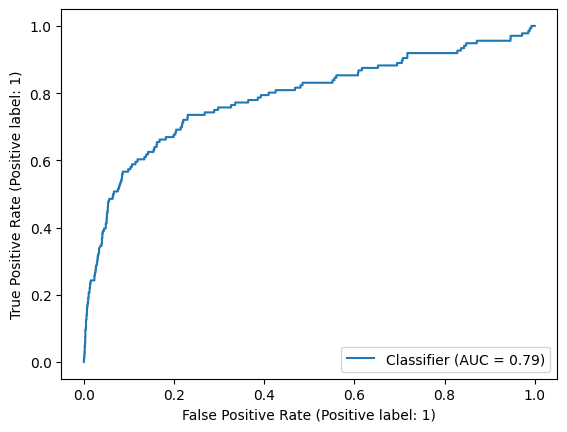

Model on last-year data:
Model metrics:
[[274  12]
 [ 21 115]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       286
           1       0.91      0.85      0.87       136

    accuracy                           0.92       422
   macro avg       0.92      0.90      0.91       422
weighted avg       0.92      0.92      0.92       422

ROC AUC: 0.9682
F1 Score: 0.8745
Execution time: 4.72 seconds


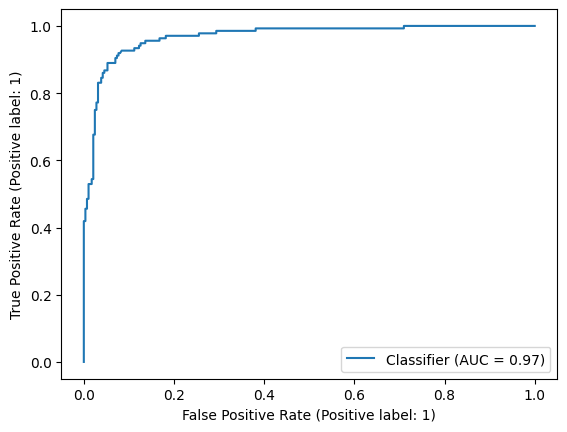

Model on extracted features:
Model metrics:
[[277   9]
 [ 22 114]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       286
           1       0.93      0.84      0.88       136

    accuracy                           0.93       422
   macro avg       0.93      0.90      0.91       422
weighted avg       0.93      0.93      0.93       422

ROC AUC: 0.9657
F1 Score: 0.8803
Execution time: 6.72 seconds


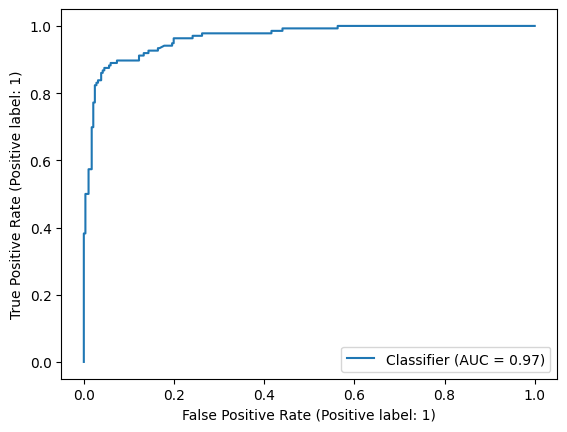

In [22]:
svm_params = {
    'kernel': 'rbf',
    'probability': True,
    'random_state': SEED
}

svm_pipeline = Pipeline([
    ('preprocessor', make_preprocessor(scaler=StandardScaler())),
    ('model', SVC(**svm_params))
])

print("Model on original data:")
svm_base_eval = evaluate_model(
    svm_pipeline,
    X,
    y,
    cv=sgkf,
    groups=groups
)
print("Model on last-year data:")
svm_last_time_eval = evaluate_model(
    svm_pipeline,
    X_last_time,
    y_last_time,
    cv=skf
)
print("Model on extracted features:")
svm_extracted_eval = evaluate_model(
    svm_pipeline,
    X_extracted,
    y_extracted,
    cv=skf
)

### Random Forest Model Evaluation

Model on original data:
Model metrics:
[[3506   30]
 [ 101   35]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3536
           1       0.54      0.26      0.35       136

    accuracy                           0.96      3672
   macro avg       0.76      0.62      0.66      3672
weighted avg       0.96      0.96      0.96      3672

ROC AUC: 0.9145
F1 Score: 0.3483
Execution time: 5.98 seconds


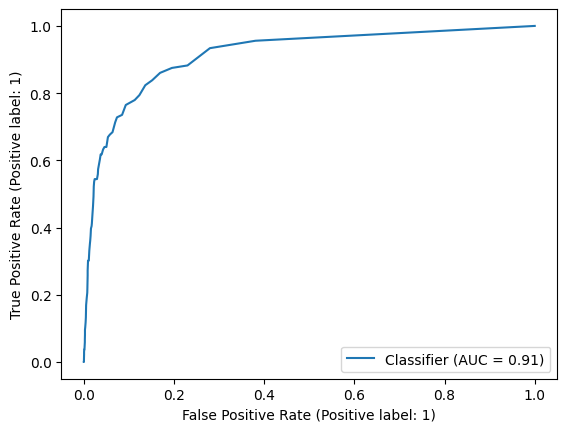

Model on last-year data:
Model metrics:
[[271  15]
 [ 10 126]]
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       286
           1       0.89      0.93      0.91       136

    accuracy                           0.94       422
   macro avg       0.93      0.94      0.93       422
weighted avg       0.94      0.94      0.94       422

ROC AUC: 0.9761
F1 Score: 0.9097
Execution time: 4.90 seconds


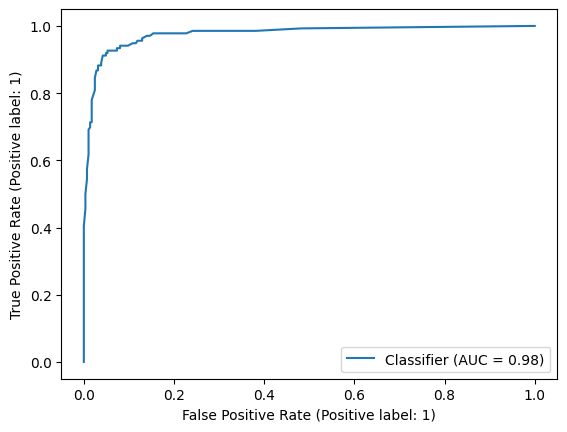

Model on extracted features:
Model metrics:
[[273  13]
 [ 11 125]]
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       286
           1       0.91      0.92      0.91       136

    accuracy                           0.94       422
   macro avg       0.93      0.94      0.94       422
weighted avg       0.94      0.94      0.94       422

ROC AUC: 0.9723
F1 Score: 0.9124
Execution time: 7.65 seconds


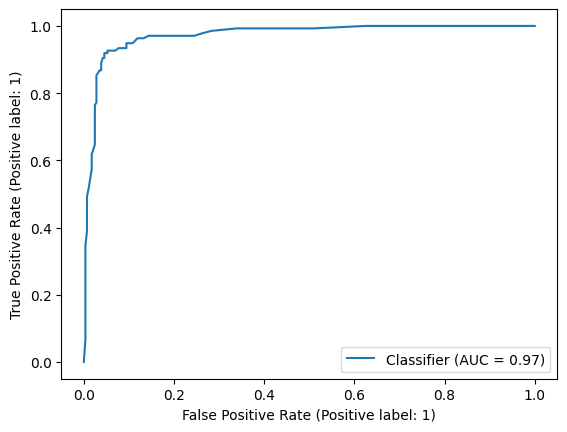

In [23]:
rf_params = {
    'n_estimators': 100,
    'random_state': SEED,
    'n_jobs': -1
}

rf_pipeline = Pipeline([
    ('preprocessor', make_preprocessor()),
    ('model', RandomForestClassifier(**rf_params))
])

print("Model on original data:")
rf_base_eval = evaluate_model(
    rf_pipeline,
    X,
    y,
    cv=sgkf,
    groups=groups
)
print("Model on last-year data:")
rf_last_time_eval = evaluate_model(
    rf_pipeline,
    X_last_time,
    y_last_time,
    cv=skf
)
print("Model on extracted features:")
rf_extracted_eval = evaluate_model(
    rf_pipeline,
    X_extracted,
    y_extracted,
    cv=skf
)

### XGBoost Model Evaluation

Model on original data:
Model metrics:
[[3505   31]
 [ 105   31]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3536
           1       0.50      0.23      0.31       136

    accuracy                           0.96      3672
   macro avg       0.74      0.61      0.65      3672
weighted avg       0.95      0.96      0.96      3672

ROC AUC: 0.9227
F1 Score: 0.3131
Execution time: 5.64 seconds


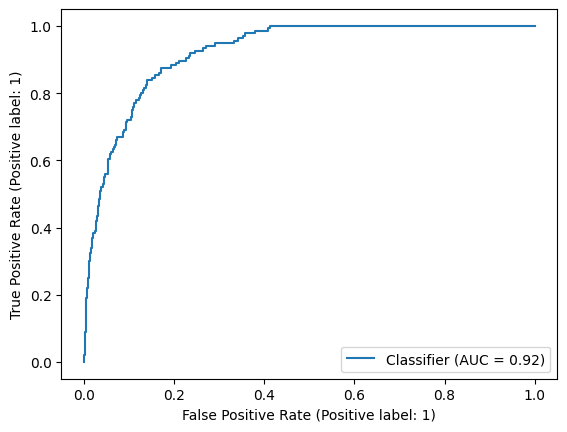

Model on last-year data:
Model metrics:
[[272  14]
 [ 13 123]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       286
           1       0.90      0.90      0.90       136

    accuracy                           0.94       422
   macro avg       0.93      0.93      0.93       422
weighted avg       0.94      0.94      0.94       422

ROC AUC: 0.9801
F1 Score: 0.9011
Execution time: 4.95 seconds


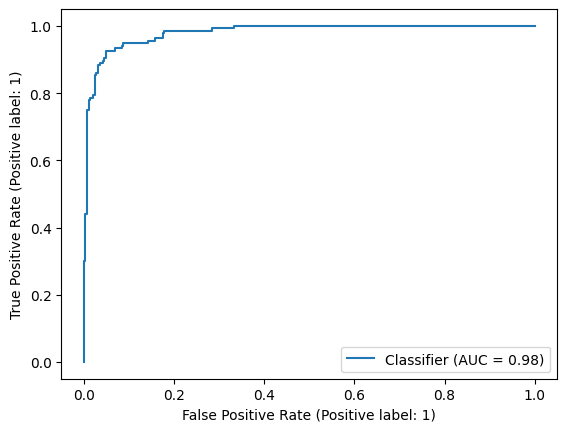

Model on extracted features:
Model metrics:
[[275  11]
 [ 11 125]]
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       286
           1       0.92      0.92      0.92       136

    accuracy                           0.95       422
   macro avg       0.94      0.94      0.94       422
weighted avg       0.95      0.95      0.95       422

ROC AUC: 0.9791
F1 Score: 0.9191
Execution time: 7.59 seconds


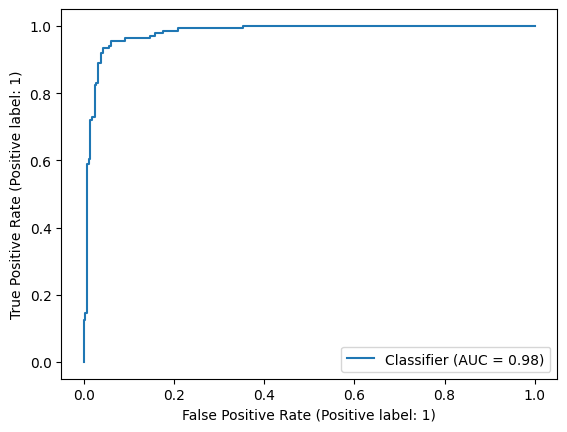

In [24]:
xgb_params = {
    'eval_metric': 'logloss',
    'random_state': SEED,
    'n_jobs': -1
}

xgb_pipeline = Pipeline([
    ('preprocessor', make_preprocessor()),
    ('model', XGBClassifier(**xgb_params))
])

print("Model on original data:")
xgb_base_eval = evaluate_model(
    xgb_pipeline,
    X,
    y,
    cv=sgkf,
    groups=groups
)
print("Model on last-year data:")
xgb_last_time_eval = evaluate_model(
    xgb_pipeline,
    X_last_time,
    y_last_time,
    cv=skf
)
print("Model on extracted features:")
xgb_extracted_eval = evaluate_model(
    xgb_pipeline,
    X_extracted,
    y_extracted,
    cv=skf
)

## 6. Model Interpretability with SHAP

The model of choice (XGBoost) is trained on the full dataset and its results are interpreted with SHAP.

The bar summary plot shows the **global importance** of each feature, while the beeswarm plot reflects the **direction and magnitude** of the effect for each instance.

In [25]:
xgb_pipeline.fit(X_extracted, y_extracted)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('reset_index',
                                  FunctionTransformer(func=<function make_preprocessor.<locals>.<lambda> at 0x7fbfcb1f8700>)),
                                 ('column_transform',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='median'))]),
                                                                   <sklearn.compose._column_transformer.make_column_selector object at 0x7fbfcc61b...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=-1,
                               num_parallel_tree=None, random_state=42, ...))])

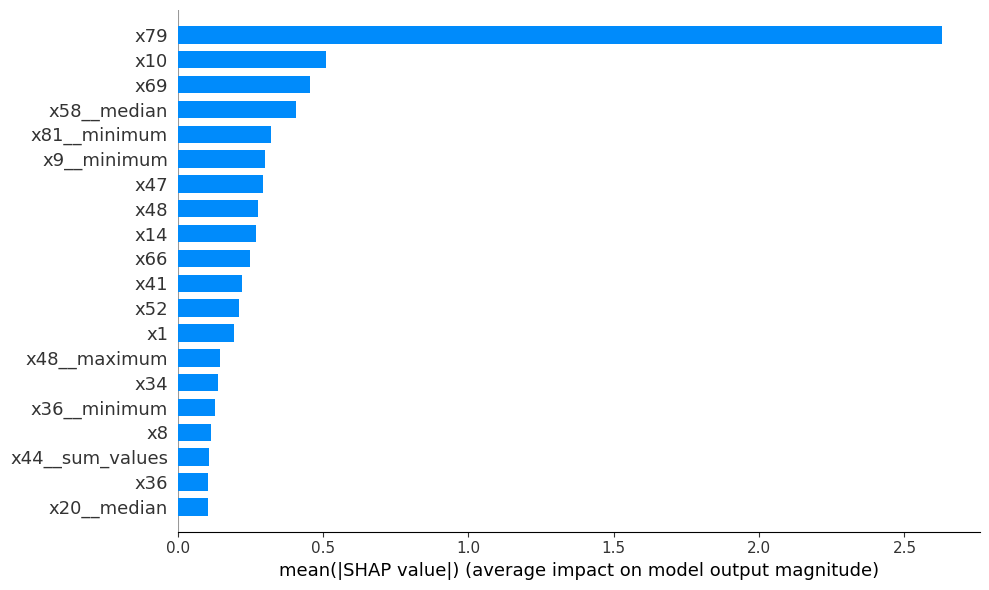

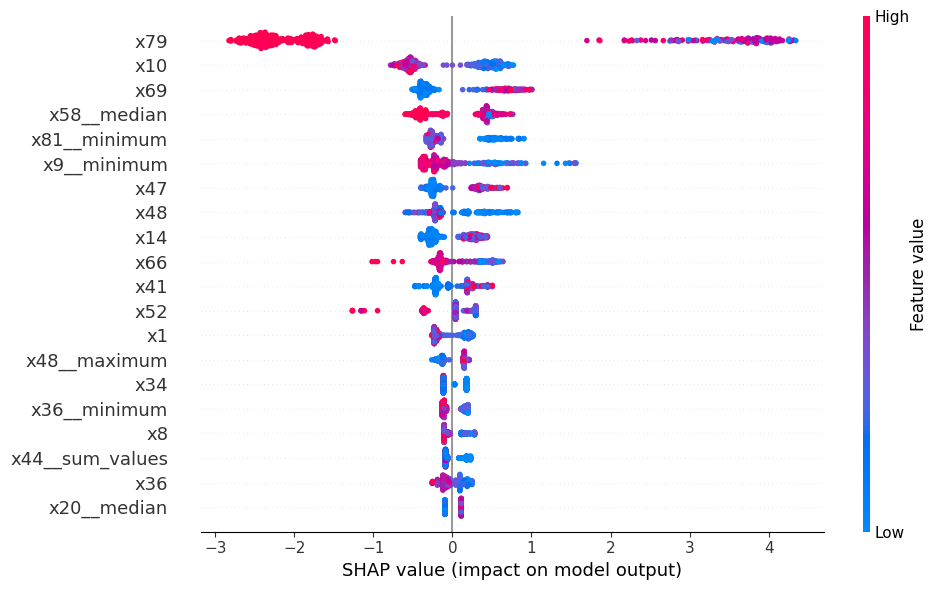

In [26]:
model = xgb_pipeline.named_steps['model']
preprocessor = xgb_pipeline.named_steps['preprocessor']
X_transformed = preprocessor.transform(X_extracted)

explainer = shap.Explainer(model, X_transformed)
shap_values = explainer(X_transformed)

shap.summary_plot(shap_values, X_transformed, plot_type='bar', plot_size=(10, 6))
shap.summary_plot(shap_values, X_transformed, plot_size=(10, 6))

## 7. Conclusions and Next Steps

### Conclusions
- **Process summary:** use case definition, dataset exploration, feature extraction with tsfresh, model evaluation across different dataframes, and final model interpretation with SHAP.
- **Selected model:** XGBoost trained on `X_extracted` — ROC-AUC: 0.9791 · F1: 0.9191. Chosen for its strong performance and ability to leverage temporal information.
- **Key findings:**
  - Marginal impact of temporal feature extraction.
  - Superiority of tree-based models.
  - Features `x79`, `x10`, and `x69` had the highest mean absolute SHAP values in the XGBoost model.

### Next Steps
1. Optimize hyperparameters with GridSearchCV.
2. Explore ensemble methods for greater robustness.
3. Expand the dataset with macroeconomic variables.

### Reflection
Although metrics did not improve with temporal features, there remains a preference for a model that incorporates them, as they provide greater robustness.

### Optional Cell – Saving the Final Model

If desired, you can uncomment the following cell to save the final model (XGBoost) and load it later with:

```python
import joblib
model = joblib.load('final_xgb_model.pkl')
```

In [27]:
# Optional: Save the final model (uncomment to execute)
# import joblib
# joblib.dump(xgb_pipeline.named_steps['model'], 'final_xgb_model.pkl')
# print("Model saved successfully.")